# Import Necessary Libraries
First, we need to import the required libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create & Prepare the Data

C:\Users\Liman\AppData\Local\Temp\ipykernel_1544\4114960619.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "Month": pd.date_range(start="2023-01-01", periods=12, freq="M"),


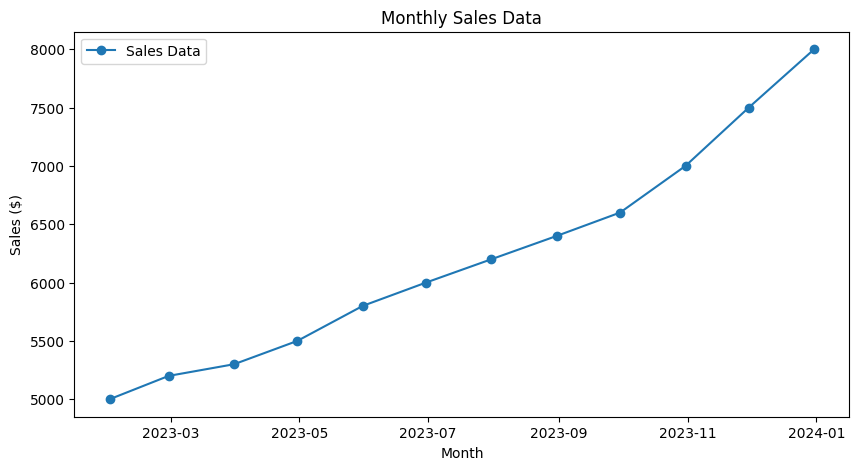

In [3]:
# Sample monthly sales data
data = {
    "Month": pd.date_range(start="2023-01-01", periods=12, freq="M"),
    "Sales": [5000, 5200, 5300, 5500, 5800, 6000, 6200, 6400, 6600, 7000, 7500, 8000]
}

df = pd.DataFrame(data)
df.set_index("Month", inplace=True)  # Set date as index

# Visualize the data
plt.figure(figsize=(10, 5))
plt.plot(df, marker="o", linestyle="-", label="Sales Data")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.title("Monthly Sales Data")
plt.legend()
plt.show()

# Train an ARIMA Model

In [4]:
# Define ARIMA model (p, d, q)
model = ARIMA(df, order=(1, 1, 1))  # (AutoRegressive=1, Differencing=1, Moving Average=1)

# Fit the model
arima_result = model.fit()

# Print model summary
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -65.883
Date:                Wed, 29 Oct 2025   AIC                            137.767
Time:                        12:09:06   BIC                            138.961
Sample:                    01-31-2023   HQIC                           137.015
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8496      0.163      5.212      0.000       0.530       1.169
ma.L1          0.9905      9.399      0.105      0.916     -17.431      19.412
sigma2      5743.8032    5.6e+04      0.103      0.9

c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARIMA Parameters (p, d, q):

* p (AutoRegressive term) → Uses past values.
* d (Differencing term) → Removes trends.
* q (Moving Average term) → Uses past errors to improve predictions.

# Make Predictions

In [5]:
# Forecast next 3 months
forecast = arima_result.forecast(steps=3)
print("Forecasted Sales:", forecast)

Forecasted Sales: 2024-01-31    8484.311400
2024-02-29    8895.779239
2024-03-31    9245.359658
Freq: ME, Name: predicted_mean, dtype: float64


# Evaluate Model Performance

In [6]:
# Split data into training (first 9 months) and test (last 3 months)
train_size = 9
train, test = df[:train_size], df[train_size:]

# Fit ARIMA on training data
model_train = ARIMA(train, order=(1, 1, 1)).fit()

# Predict on test set
predictions = model_train.forecast(steps=len(test))

# Calculate Errors
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Mean Absolute Error (MAE): 502.19688246209415
Mean Squared Error (MSE): 312642.2741109598
Root Mean Squared Error (RMSE): 559.1442337277206


c:\Users\Liman\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Visualizing Predictions

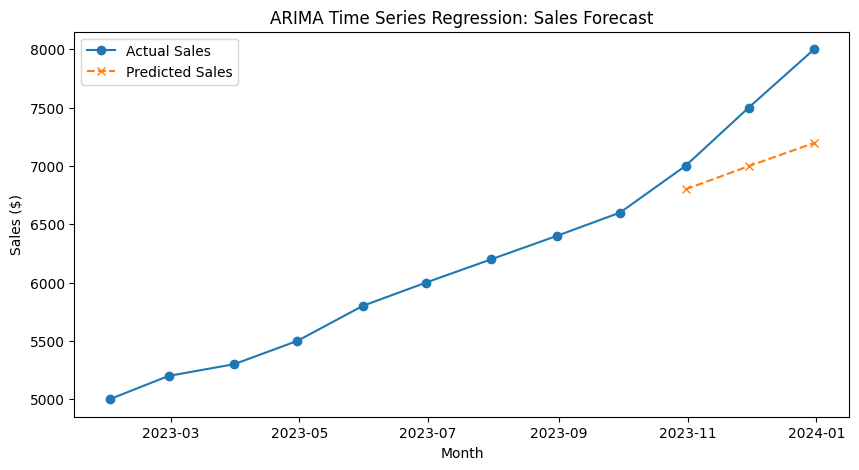

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Sales"], label="Actual Sales", marker="o")
plt.plot(test.index, predictions, label="Predicted Sales", linestyle="dashed", marker="x")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.title("ARIMA Time Series Regression: Sales Forecast")
plt.legend()
plt.show()